In [123]:
import h5py
import pylab as plt
import numpy as np
from matplotlib.dates import num2date
from datetime import datetime


# Load Samples Data

In [76]:
hdf_samples = h5py.File('../data/validate_bcube_samples_exp59.h5')
Bcube_samples = hdf_samples['Bcube'][:].max(axis=1)
times_d2n = hdf_samples['times_d2n'][:]
hdf_samples.close()

In [77]:
norm_samples = np.linalg.norm(Bcube_samples, axis=-1)
max_norm_samples = np.max(norm_samples, axis=(1, 2))

In [78]:
times_samples = num2date(times_d2n)

# Load Validation Data

In [130]:
hdf_val = h5py.File('../data/validate_bcube_valdata.h5')
Bcube_val = hdf_val['Bcube'][:].max(axis=1)
hdf_val.close()

In [131]:
norm_val = np.linalg.norm(Bcube_val, axis=-1)
max_norm_val = np.max(norm_val, axis=(1, 2))

# Plot Experiment

In [134]:
sf = 1e-2 # uT to G

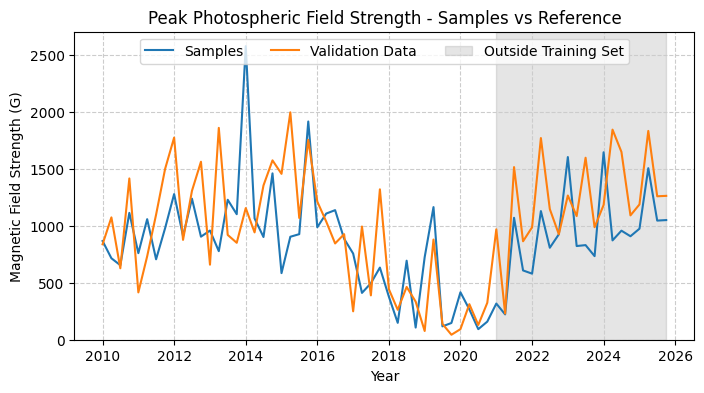

In [141]:
plt.figure(figsize=(8, 4))
plt.plot(times_samples, sf * max_norm_samples[:,0], label='Samples')
plt.ylabel('Magnetic Field Strength (G)')
plt.plot(times_samples, sf *  max_norm_val[:, 0], label='Validation Data', color='C1')
plt.title('Peak Photospheric Field Strength - Samples vs Reference')

_, L = plt.ylim()
plt.ylim(0, L)
plt.fill_between([datetime(2021, 1, 1), times_samples[-1]], 0, L, color='k', alpha=0.1, label='Outside Training Set')
plt.legend(loc='upper center', ncol=3)
plt.xlabel('Year')
plt.grid(color='#ccc', linestyle='dashed')
plt.savefig('../plots/paper/photospheric_field_strength.png', dpi=300)